# 05 - Topic Analysis

We build the speech topics from the **fine-tuned embeddings** (BERTopic on the Jina vectors, `min_topic_size = 150`) - i.e. speeches are clustered by meaning, not by word overlap.

We keep two assignments: the raw one (BERTopic leaves the vague speeches as `-1`) and a reduced one where every leftover speech goes to its nearest topic. At the end we save both, together with the topic names.

In [1]:
!pip install bertopic nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.6 MB/s eta 0:00:00


In [2]:
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bertopic import BERTopic
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

## 1. Load the data

In [5]:
# full fine-tuned embedding dataset, already containing the speech texts
df = pd.read_parquet("jina_v3_contrastive_full.parquet")  #adjust in case offtheshelf yields better results
df = df[df["speechContent"].notna() & (df["speechContent"].str.strip() != "")].reset_index(drop=True)

docs = [unicodedata.normalize("NFC", t) for t in df["speechContent"].tolist()]
embeddings = np.array(df["embedding"].tolist(), dtype="float32")

print(f"{len(df):,} speeches")
print("columns:", list(df.columns))
print("umlaut check:", repr(docs[0][:100]))

82,447 speeches
columns: ['id', 'speechContent', 'politicianId', 'politicianName', 'firstName', 'lastName', 'positionShort', 'factionId', 'party', 'date', 'year', 'year_month', 'n_tokens', 'used_in_finetune', 'used_in_party_probe_val', 'used_in_party_probe_test', 'used_finetuned_weights', 'embedding']
umlaut check: 'Meine werten Kolleginnen und Kollegen! Liebe Kolleginnen und Kollegen von der Union, Sie müssen unte'


**82,447 speeches** loaded straight from the embedding file (text and vector live in the same table). The umlaut check prints real ü / ä / ö, so the German text survived the import intact.

## Shared text settings (umlaut-safe)

In [6]:
def strip_accents(w):
    return unicodedata.normalize("NFKD", w).encode("ascii", "ignore").decode("ascii")

plenary = [
    "herr", "frau", "damen", "herren", "kollege", "kollegin", "kolleginnen",
    "kollegen", "präsident", "präsidentin", "dank", "danke", "vielen", "sehr",
    "geehrter", "geehrte", "liebe", "meine", "schon", "mehr", "gibt", "heute",
    "gesagt", "gesetzentwurf", "antrag", "deutschland", "bundesregierung",
    "können", "müssen", "worden", "ganz", "wäre", "gerne", "sagen", "geht", "immer",
]
filler = ["ja", "dafür", "natürlich", "tun", "gut", "wirklich", "wissen", "brauchen",
          "thema", "glaube", "wichtig", "deswegen", "punkt", "möchte", "bereits",
          "deshalb", "dabei", "sowie", "mal", "endlich", "eigentlich", "sage",
          "wer", "reden", "darüber", "nehmen", "hätte", "hätten", "sei", "herrn"]
base = set(stopwords.words("german")) | set(plenary) | set(filler)
german_stop = sorted(base | {strip_accents(w) for w in base})

german_token = r"(?u)\b[A-Za-zÄÖÜäöüß][A-Za-zÄÖÜäöüß-]+\b"

## 2. Embedding-based topics (BERTopic, min size 150).

In [7]:
vectorizer = CountVectorizer(stop_words=german_stop, strip_accents=None,
                             token_pattern=german_token, min_df=10, ngram_range=(1, 2))

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric="cosine", init="random", random_state=42)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    vectorizer_model=vectorizer,
    min_topic_size=150,
    calculate_probabilities=False,
    verbose=True,
)

topics_raw = topic_model.fit_transform(docs, embeddings=embeddings)[0]

2026-08-15 11:00:24,740 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-15 11:01:52,618 - BERTopic - Dimensionality - Completed ✓
2026-08-15 11:01:52,622 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-15 11:02:06,044 - BERTopic - Cluster - Completed ✓
2026-08-15 11:02:06,068 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-15 11:03:20,572 - BERTopic - Representation - Completed ✓


In [8]:
df["topic_emb_raw"] = topics_raw
topics_full = topic_model.reduce_outliers(docs, topics_raw, strategy="embeddings",
                                          embeddings=embeddings, threshold=0.0)
df["topic_emb_full"] = topics_full

n_topics = len([t for t in set(topics_raw) if t != -1])
print(f"{n_topics} embedding topics")
print(f"path A unassigned: {(df['topic_emb_raw']  == -1).mean():.0%}")
print(f"path B unassigned: {(df['topic_emb_full'] == -1).mean():.0%}")

52 embedding topics
path A unassigned: 23%
path B unassigned: 0%


BERTopic found **52 topics** from the embeddings. **Path A** leaves **23%** of speeches unassigned (`-1`) — the vague / mixed ones HDBSCAN won't force into a cluster. **Path B** reassigns those to their nearest topic, so every speech gets a label. At `min_topic_size=150` the topics stay balanced — no single dominating topic.

### Umlaut-correct topic labels

BERTopic's own labels strip the umlauts, so we build labels ourselves from a plain CountVectorizer (keeps umlauts) using an over-representation score.

In [9]:
label_vec = CountVectorizer(stop_words=german_stop, strip_accents=None,
                            token_pattern=german_token, min_df=20)
X_label = label_vec.fit_transform(docs)
vocab_label = np.array(label_vec.get_feature_names_out())
overall = np.asarray(X_label.sum(axis=0)).ravel() + 1

def label_topics(topic_col, n=3):
    labels, arr = {}, df[topic_col].to_numpy()
    for t in sorted(set(arr)):
        if t == -1:
            continue
        cnt = np.asarray(X_label[arr == t].sum(axis=0)).ravel()
        lift = (cnt / max(cnt.sum(), 1)) / (overall / overall.sum())
        lift[cnt < 20] = 0
        labels[t] = f"{t}: " + "/".join(vocab_label[lift.argsort()[::-1][:n]])
    return labels

emb_labels = label_topics("topic_emb_raw")

counts = df["topic_emb_raw"].value_counts()
overview = (pd.DataFrame([{"topic": t, "count": int(counts.get(t, 0)), "label": lab}
                          for t, lab in emb_labels.items()])
            .sort_values("count", ascending=False).reset_index(drop=True))
overview

,topic,count,label
0,0,11096,0: finanzplatzes/pfandbrief/mittelstandsfinanz...
1,1,5878,1: netznutzungsentgelte/wärmegesetz/zuteilungs...
2,2,5410,2: dreibus/zeitarbeitnehmer/rentenanpassungen
3,3,4190,3: studienfinanzierung/afbg/bafög-bericht
4,4,3670,4: tierhalter/imker/ställe
5,5,2827,5: rsa/krankenhausstrukturgesetz/drgs
6,6,2466,6: straßenbaubericht/pällmann-kommission/unfal...
7,7,2013,7: mehrstaatigkeit/schutzberechtigten/übermitt...
8,8,1499,8: epas/konfliktmineralien/deg
9,9,1482,9: mietenbericht/bestandsmieten/baulandkommission


In [12]:
biggest_category_count = overview.iloc[0]['count']
total_speeches = len(df)
percentage = (biggest_category_count / total_speeches) * 100

print(f"The biggest speech category accounts for {percentage:.2f}% of all speeches.")

The biggest speech category accounts for 13.46% of all speeches.


The **52 topics, largest first**. The biggest is ~13,46% of all speeches.
Labels are each topic's most *over-represented* words, umlauts intact; the themes are specific and readable (energy, Greece/Grexit, migration, childcare, …).

## 3. Topics over time

Share of each year's speeches per topic. With this many topics one plot is unreadable, so we draw them in batches of ~10 (biggest topics first), once per path.

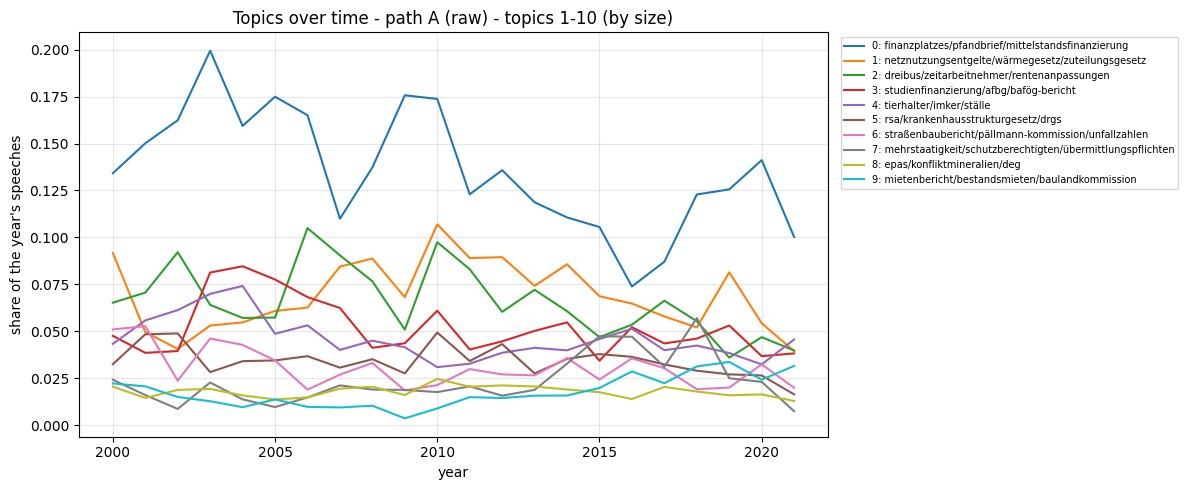

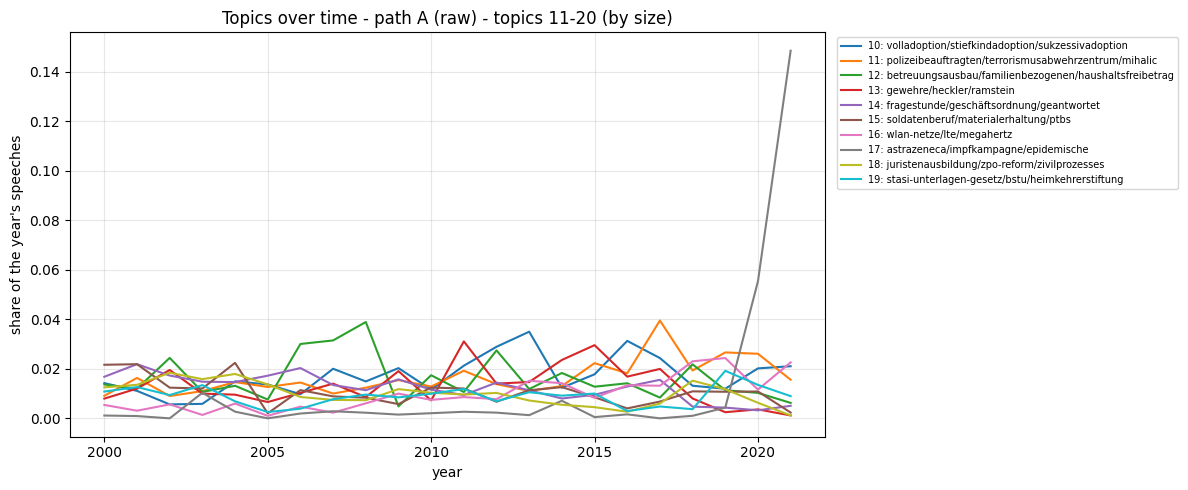

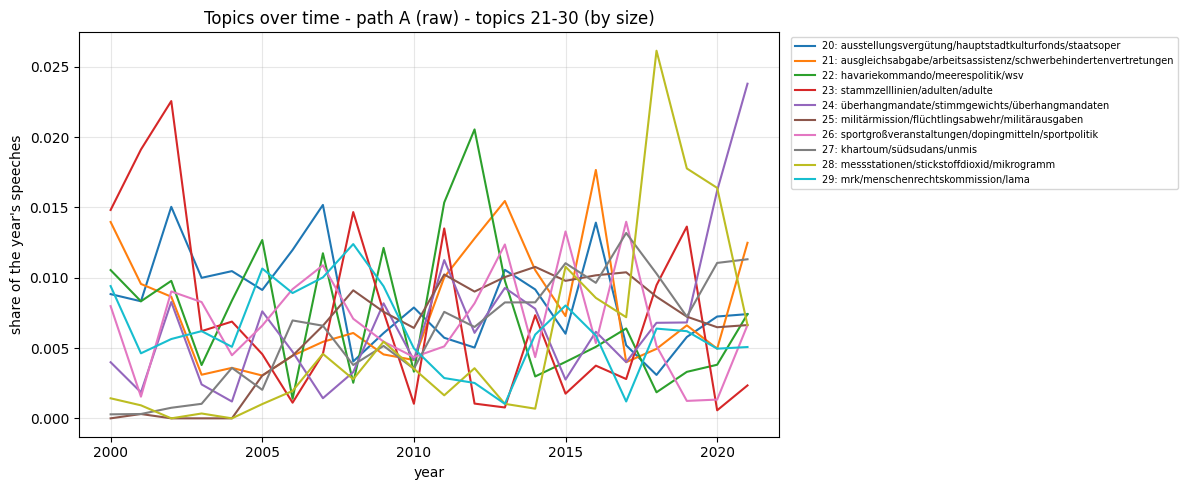

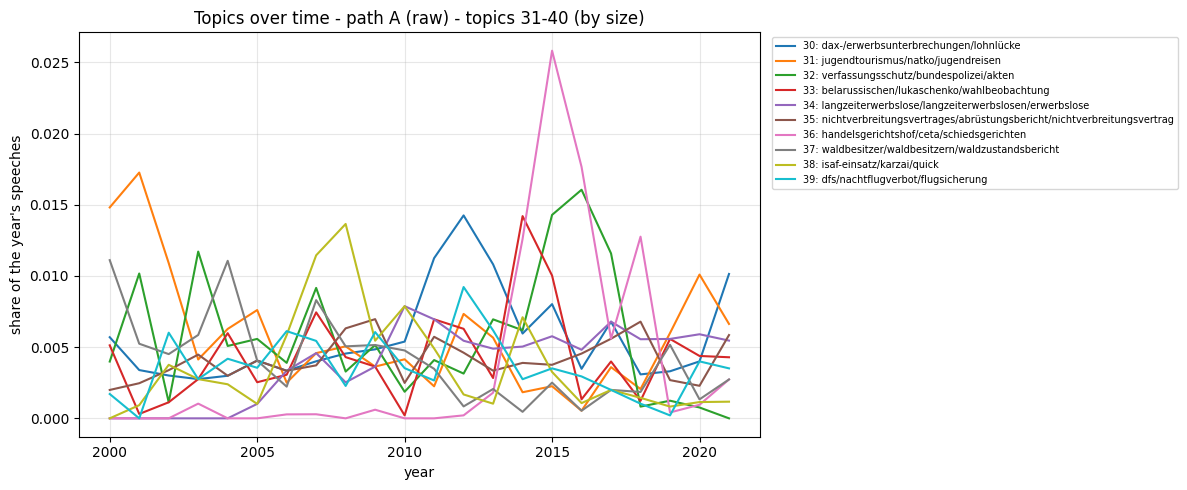

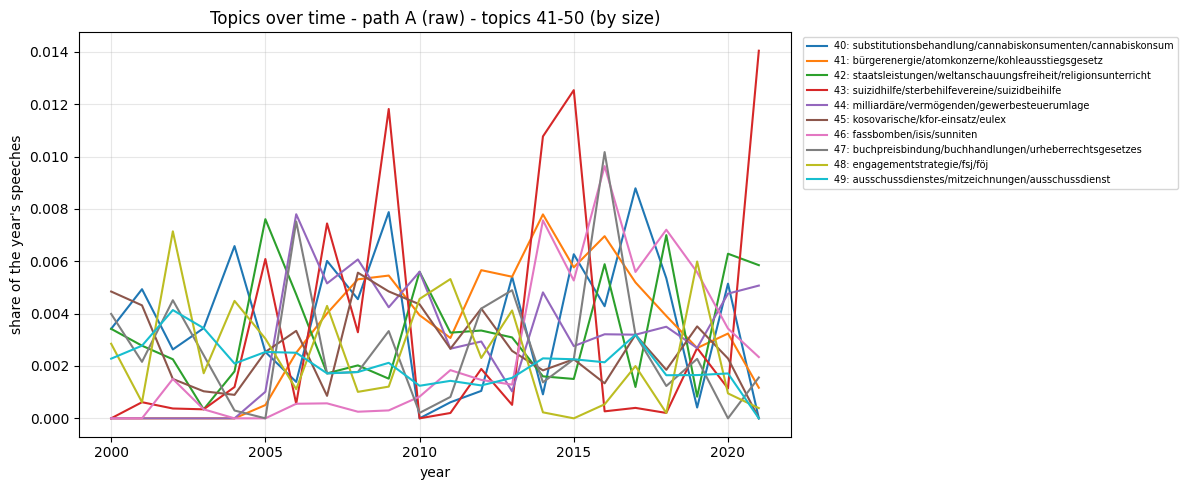

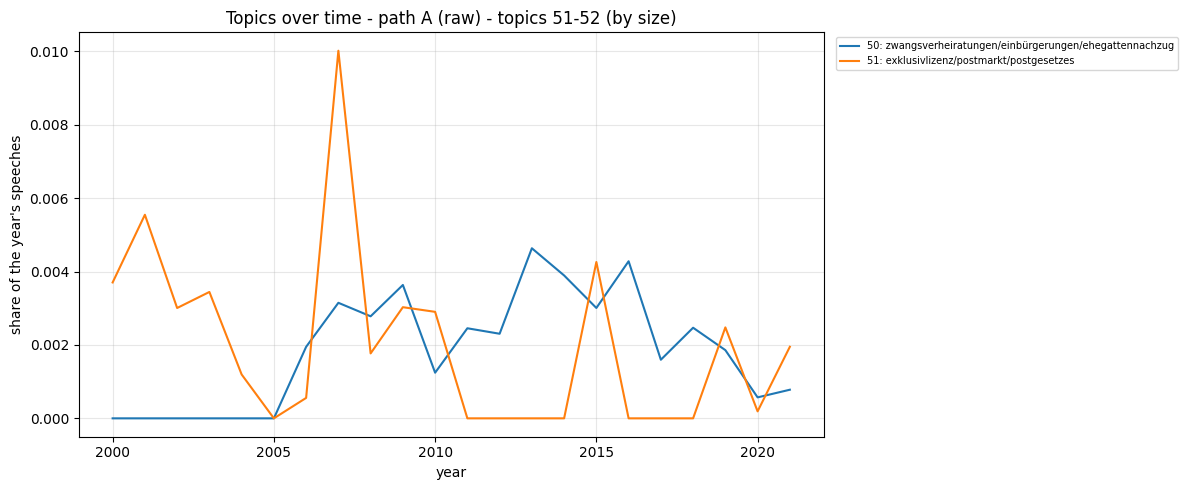

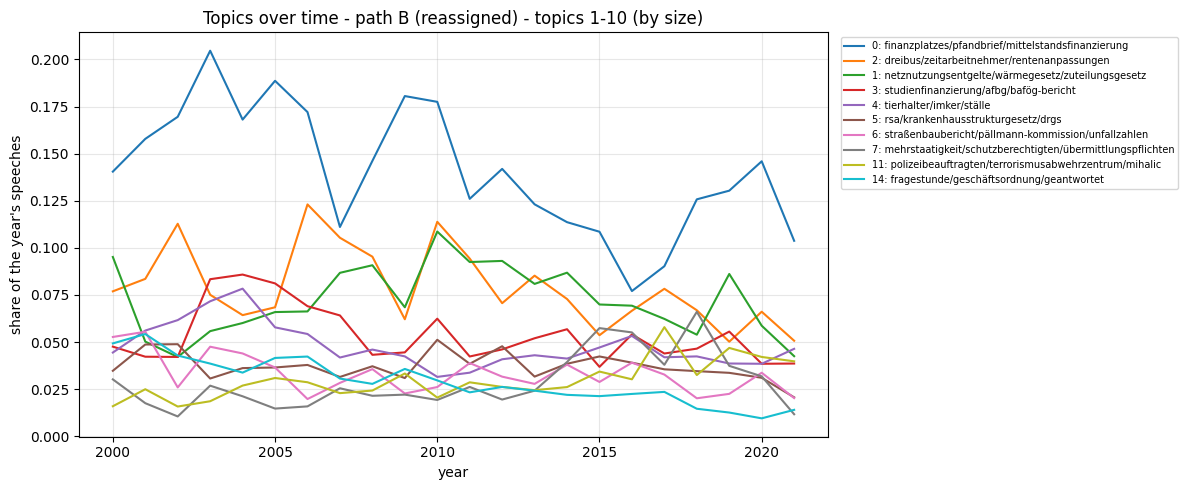

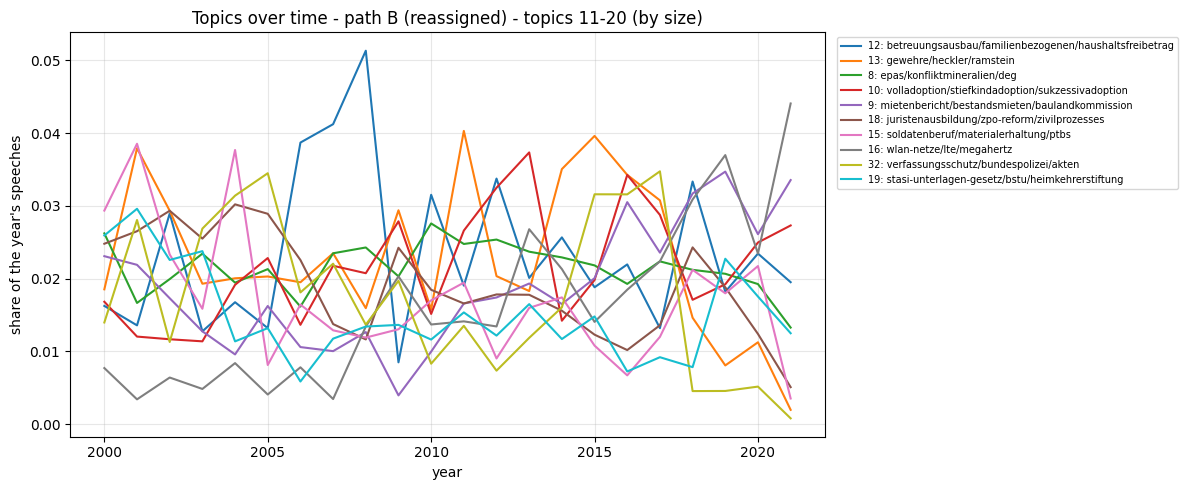

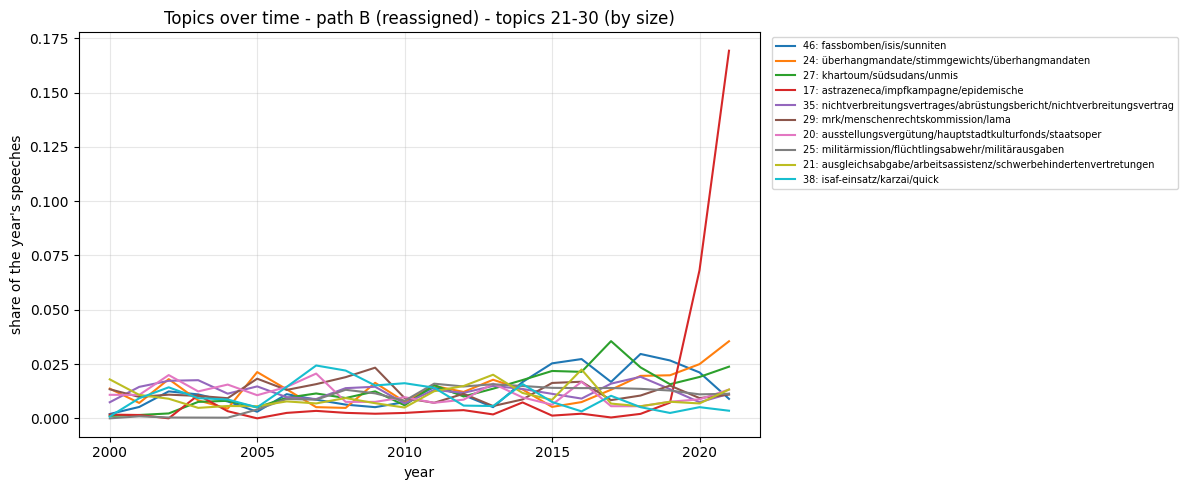

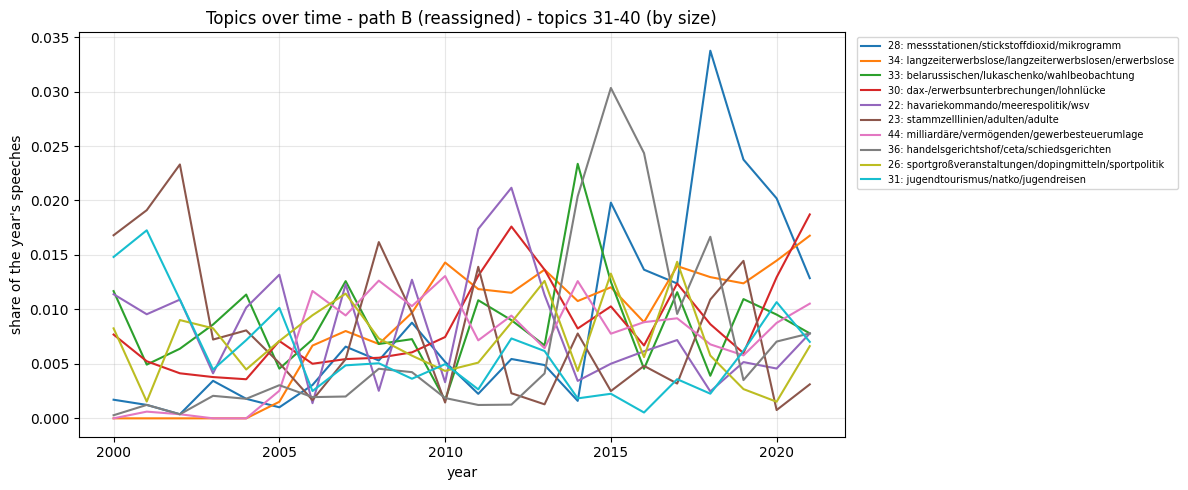

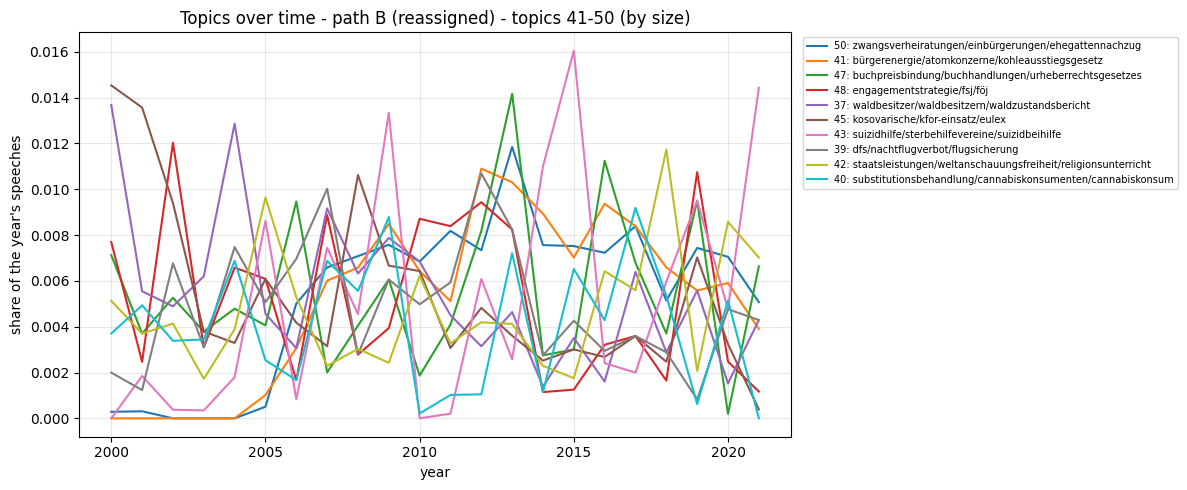

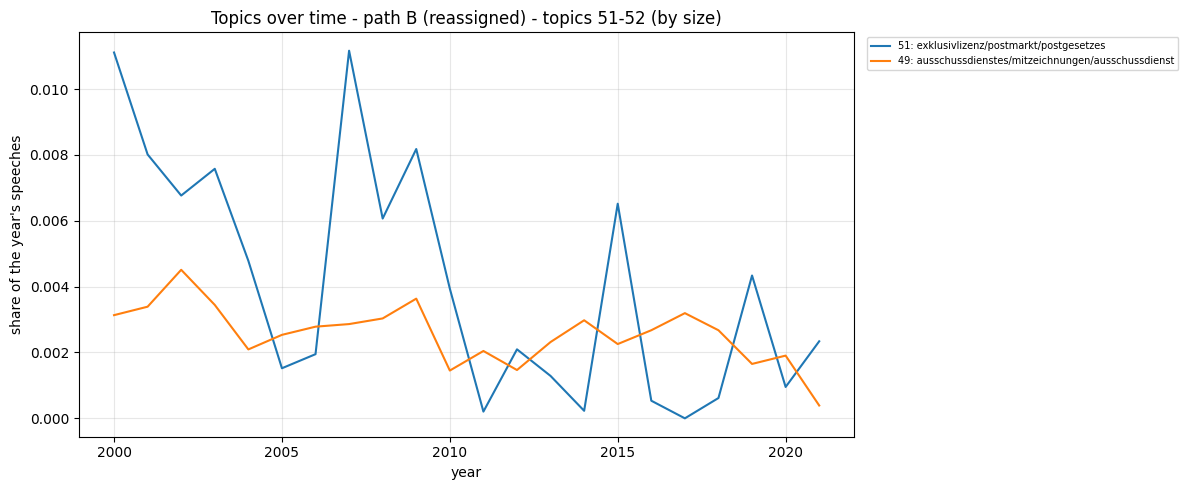

In [13]:
def topics_over_time(topic_col, title, per_plot=10):
    share = pd.crosstab(df["year"], df[topic_col], normalize="index")
    order = df.loc[df[topic_col] != -1, topic_col].value_counts().index.tolist()   # biggest first
    for i in range(0, len(order), per_plot):
        chunk = order[i:i + per_plot]
        ax = share[chunk].plot(figsize=(12, 5))
        ax.set_xlabel("year"); ax.set_ylabel("share of the year's speeches")
        ax.set_title(f"{title} - topics {i + 1}-{i + len(chunk)} (by size)")
        ax.legend([emb_labels[t] for t in chunk], bbox_to_anchor=(1.01, 1),
                  loc="upper left", fontsize=7)
        ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

topics_over_time("topic_emb_raw",  "Topics over time - path A (raw)")
topics_over_time("topic_emb_full", "Topics over time - path B (reassigned)")

Each line is a topic's **share of that year's speeches**. Event-driven topics rise and fall on cue (the pandemic topic from 2020, migration around 2015). Path A and Path B tell the same story; Path B's shares sit slightly higher because the reassigned 23% are spread back across the topics.

We could use this graphes also for event analysis.
  -> within-topic movement of parties

## 4. Topic share per party

Share of each party's speeches per topic (row-normalised by party), all topics, once per path.

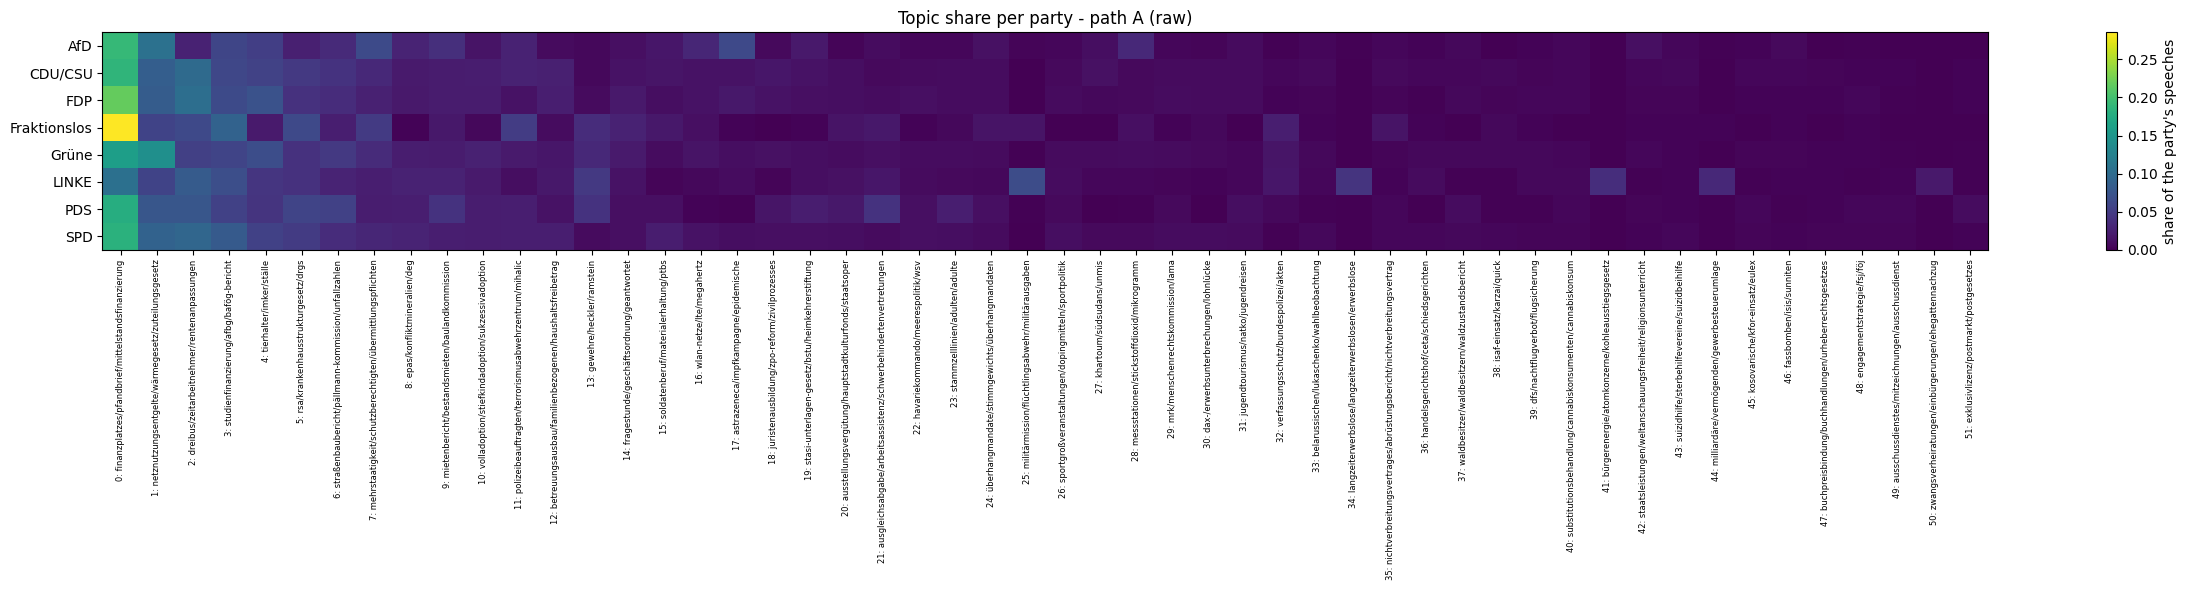

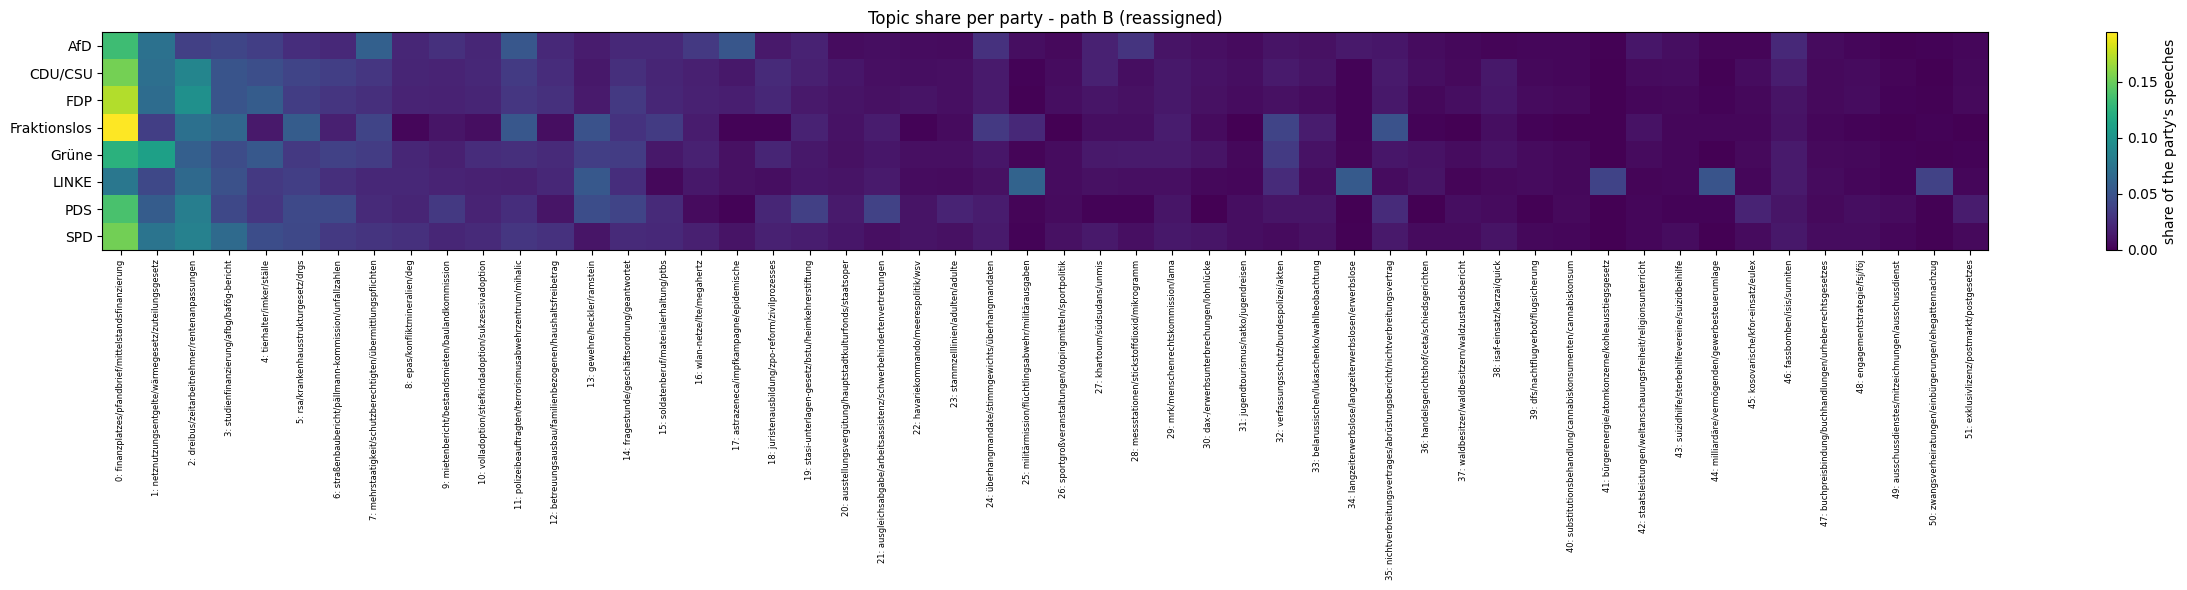

In [15]:
def topic_share_per_party(topic_col, title):
    d = df[df[topic_col] != -1]
    topics = sorted(d[topic_col].unique())
    prof = pd.crosstab(d["party"], d[topic_col], normalize="index")[topics]

    fig, ax = plt.subplots(figsize=(0.4 * len(topics) + 4, 6))
    im = ax.imshow(prof.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(topics)))
    ax.set_xticklabels([emb_labels[t] for t in topics], rotation=90, fontsize=6)
    ax.set_yticks(range(len(prof.index))); ax.set_yticklabels(prof.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="share of the party's speeches")
    plt.tight_layout(); plt.show()

topic_share_per_party("topic_emb_raw",  "Topic share per party - path A (raw)")
topic_share_per_party("topic_emb_full", "Topic share per party - path B (reassigned)")

Each **row is a party's topic profile** — the share of *its* speeches on each topic (normalised per party, so parties are comparable despite very different speech counts). Bright cells show where a party over-indexes on a theme; flat columns are shared parliamentary business.

Would be more readable if split in severak graphes with less topics/focus on most important topics, but not relevant fir report anyways

## 5. Embedding clusters in 2D

In [16]:
import umap
N = 20000
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=min(N, len(df)), replace=False)
xy = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="cosine",
               init="random", random_state=42).fit_transform(embeddings[idx])

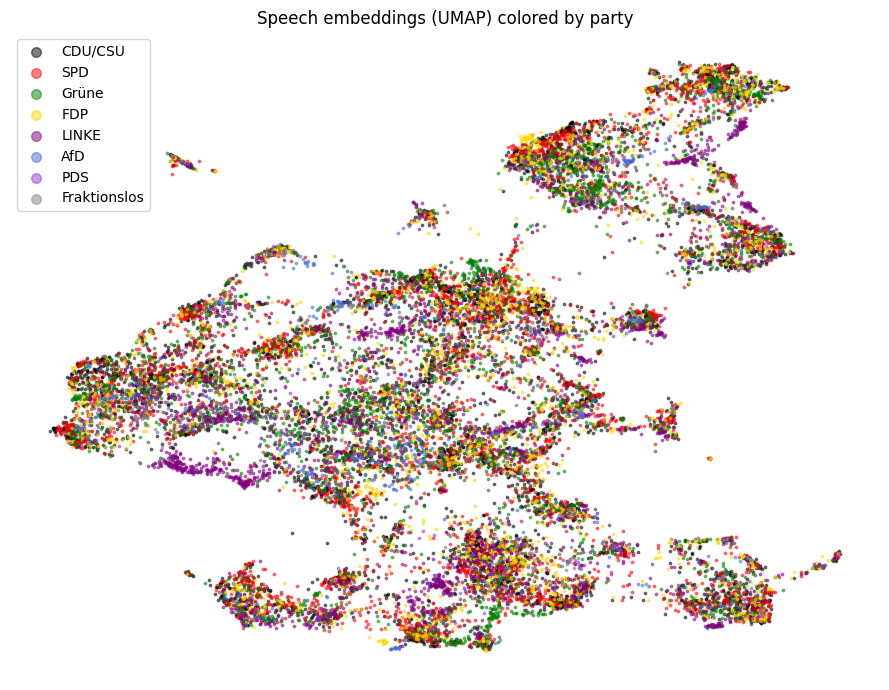

In [17]:
party_sample = df["party"].to_numpy()[idx]
party_colors = {"CDU/CSU": "black", "SPD": "red", "Grüne": "green", "FDP": "gold",
                "LINKE": "purple", "DIE LINKE.": "purple", "AfD": "royalblue",
                "PDS": "darkorchid", "Fraktionslos": "grey"}

fig, ax = plt.subplots(figsize=(9, 7))
for p, c in party_colors.items():
    m = party_sample == p
    if m.any():
        ax.scatter(xy[m, 0], xy[m, 1], s=3, alpha=0.5, color=c, label=p)
ax.legend(markerscale=4); ax.axis("off")
ax.set_title("Speech embeddings (UMAP) colored by party")
plt.tight_layout(); plt.show()

Speech embeddings in 2D, coloured by **party**. The colours are largely **mixed** — speeches barely separate by party, because what a speech is *about* dominates its embedding far more than who gave it. (This is also why the ideological signal is weak.)

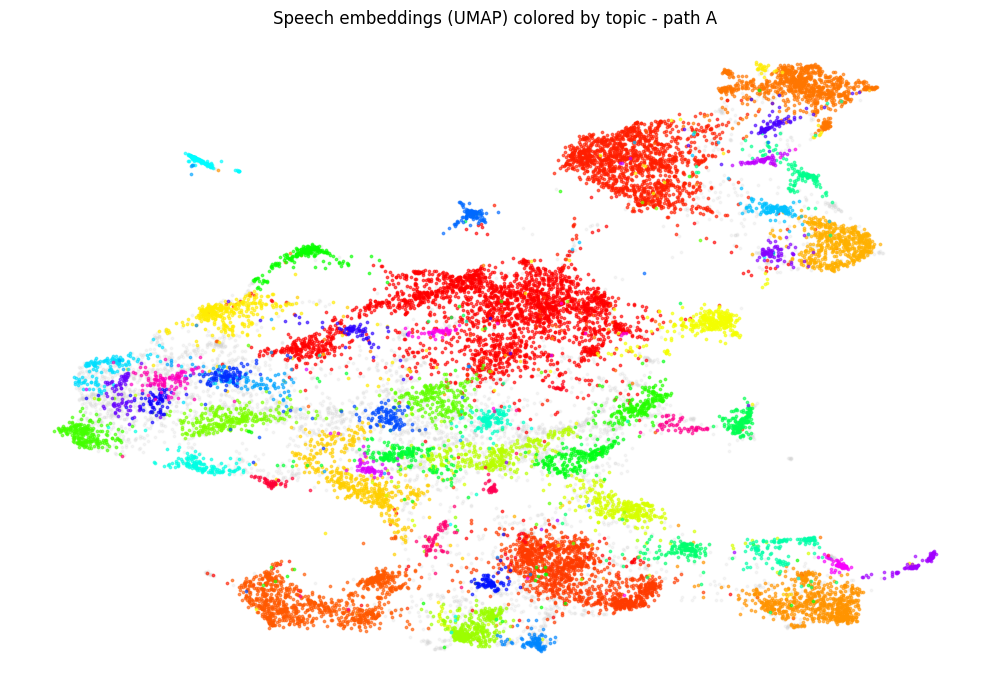

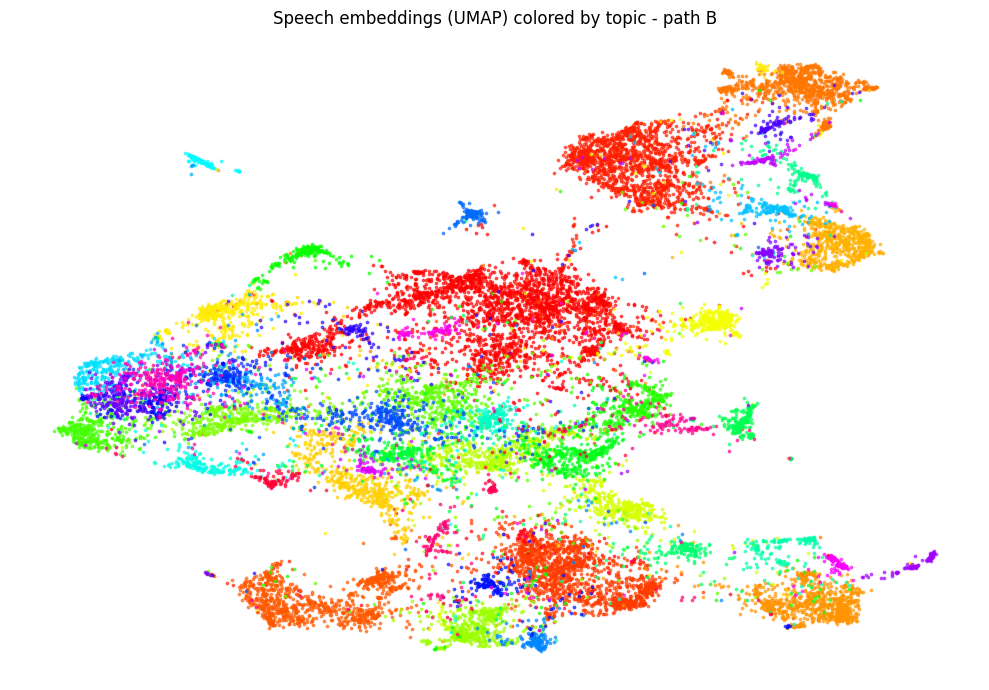

In [18]:
def scatter_by_topic(topic_col, title):
    ts = df[topic_col].to_numpy()[idx]
    topics = [t for t in sorted(set(ts)) if t != -1]
    cmap = plt.get_cmap("hsv", len(topics))
    fig, ax = plt.subplots(figsize=(10, 7))
    m1 = ts == -1
    if m1.any():
        ax.scatter(xy[m1, 0], xy[m1, 1], s=3, alpha=0.2, color="lightgrey", label="-1")
    for i, t in enumerate(topics):
        m = ts == t
        if m.any():
            ax.scatter(xy[m, 0], xy[m, 1], s=3, alpha=0.6, color=cmap(i))
    ax.axis("off"); ax.set_title(title)
    plt.tight_layout(); plt.show()

scatter_by_topic("topic_emb_raw",  "Speech embeddings (UMAP) colored by topic - path A")
scatter_by_topic("topic_emb_full", "Speech embeddings (UMAP) colored by topic - path B")

The same points coloured by **topic** break into clean, separated islands — the embedding space is organised by subject, not party. Path A shows the grey `-1` cloud (unassigned speeches); Path B colours it in.

## 6. Save the assignments

In [19]:
# readable name per topic, taken from the label words
topic_names = {t: lab.split(": ", 1)[1] for t, lab in emb_labels.items()}
topic_names[-1] = "unassigned"

out = (df[["politicianId", "party", "id", "topic_emb_raw", "topic_emb_full", "date"]]
       .rename(columns={"politicianId": "speaker_id", "id": "speech_id"}))
out["topic_emb_raw_name"] = out["topic_emb_raw"].map(topic_names)
out["topic_emb_full_name"] = out["topic_emb_full"].map(topic_names)
out = out[["speaker_id", "party", "speech_id",
           "topic_emb_raw", "topic_emb_raw_name",
           "topic_emb_full", "topic_emb_full_name", "date"]]

out.to_csv("speech_topic_assignments.csv", index=False, encoding="utf-8")
print(f"wrote {len(out):,} rows to speech_topic_assignments.csv")
out.head()

wrote 82,447 rows to speech_topic_assignments.csv


,speaker_id,party,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name,date
0,11001434,SPD,604683,1,netznutzungsentgelte/wärmegesetz/zuteilungsgesetz,1,netznutzungsentgelte/wärmegesetz/zuteilungsgesetz,2000-01-19
1,11002754,CDU/CSU,604883,3,studienfinanzierung/afbg/bafög-bericht,3,studienfinanzierung/afbg/bafög-bericht,2000-01-20
2,11000431,SPD,604885,3,studienfinanzierung/afbg/bafög-bericht,3,studienfinanzierung/afbg/bafög-bericht,2000-01-20
3,11001180,FDP,604905,22,havariekommando/meerespolitik/wsv,22,havariekommando/meerespolitik/wsv,2000-01-20
4,11003216,CDU/CSU,605067,-1,unassigned,15,soldatenberuf/materialerhaltung/ptbs,2000-01-21


Final deliverable: **`speech_topic_assignments.csv`**, one row per speech — speaker, party, speech id, both embedding topic paths (`topic_emb_raw` / `topic_emb_full`) with their topic **names**, and the date. This is what the trajectory notebook reads.